<a href="https://colab.research.google.com/github/sonjoy1s/Kaggle_Deep_Lr/blob/main/Social_Network_Ads.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [13]:
# Data Loading
df = pd.read_csv('/content/Social_Network_Ads.csv')
display(df.head())
df = df.iloc[:,2:]

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [14]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [15]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [16]:
# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [17]:
#Model
class Model(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(2,128)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(128,1)
    self.sigmoid = nn.Sigmoid()

  def forward(self,x):
    x = self.relu(self.fc1(x))
    x = self.sigmoid(self.fc2(x))
    return x

In [18]:
model = Model()

In [19]:
#Loss & Optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)


In [20]:
# Training
epochs = 100
val_acc_list = []

for epoch in range(epochs):
    # Forward
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    # Backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Validation
    with torch.no_grad():
        val_outputs = model(X_test)
        preds = (val_outputs > 0.5).float()
        acc = (preds == y_test).float().mean()
        val_acc_list.append(acc.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}, Val Acc: {acc.item():.4f}")

Epoch 0, Loss: 64.0625, Val Acc: 0.3500
Epoch 10, Loss: 64.0625, Val Acc: 0.3500
Epoch 20, Loss: 64.0625, Val Acc: 0.3500
Epoch 30, Loss: 64.0625, Val Acc: 0.3500
Epoch 40, Loss: 64.0625, Val Acc: 0.3500
Epoch 50, Loss: 64.0625, Val Acc: 0.3500
Epoch 60, Loss: 64.0625, Val Acc: 0.3500
Epoch 70, Loss: 64.0625, Val Acc: 0.3500
Epoch 80, Loss: 64.0625, Val Acc: 0.3500
Epoch 90, Loss: 64.0625, Val Acc: 0.3500


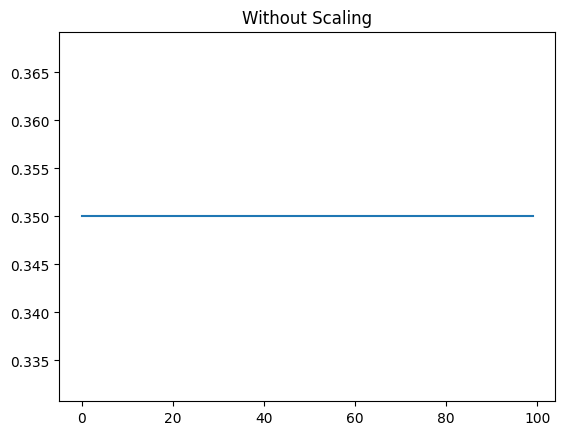

In [21]:
# Plot
plt.plot(val_acc_list)
plt.title("Without Scaling")
plt.show()

Epoch 0, Loss: 0.7056, Val Acc: 0.3500
Epoch 10, Loss: 0.6053, Val Acc: 0.8500
Epoch 20, Loss: 0.5317, Val Acc: 0.8500
Epoch 30, Loss: 0.4792, Val Acc: 0.8500
Epoch 40, Loss: 0.4418, Val Acc: 0.8500
Epoch 50, Loss: 0.4145, Val Acc: 0.8750
Epoch 60, Loss: 0.3936, Val Acc: 0.8875
Epoch 70, Loss: 0.3770, Val Acc: 0.9125
Epoch 80, Loss: 0.3630, Val Acc: 0.9000
Epoch 90, Loss: 0.3508, Val Acc: 0.9125


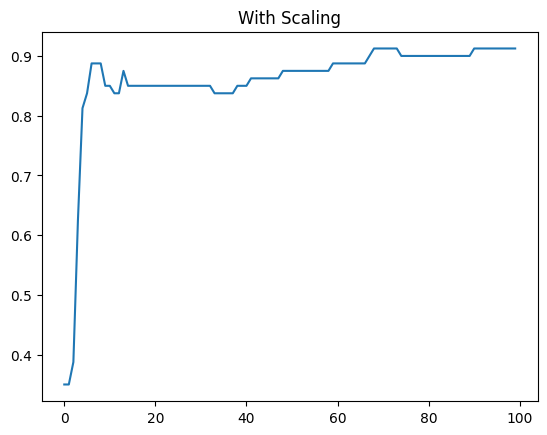

In [22]:
from sklearn.preprocessing import StandardScaler

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.numpy())
X_test_scaled = scaler.transform(X_test.numpy())

# Convert back to tensor
X_train_scaled = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_scaled = torch.tensor(X_test_scaled, dtype=torch.float32)

# New model
model = Model()

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 100
val_acc_list_scaled = []

for epoch in range(epochs):
    # Forward
    outputs = model(X_train_scaled)
    loss = criterion(outputs, y_train)

    # Backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Validation
    with torch.no_grad():
        val_outputs = model(X_test_scaled)
        preds = (val_outputs > 0.5).float()
        acc = (preds == y_test).float().mean()
        val_acc_list_scaled.append(acc.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}, Val Acc: {acc.item():.4f}")

# Plot
plt.plot(val_acc_list_scaled)
plt.title("With Scaling")
plt.show()

🔍 What this second graph shows

Accuracy jumps quickly → ~0.88 early

Then stabilizes around 0.83–0.85

Small fluctuations (normal)

👉 Most important:

The model is actually learning now

